In [1]:
#decision tree regressor

import matplotlib.pyplot
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split


In [2]:
df= load_diabetes(as_frame= True).frame

In [3]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [4]:
df.shape

(442, 11)

In [5]:
X=df.drop("target",axis=1)
y=df["target"]

In [6]:
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [7]:
X_train, X_test, y_train, y_test= train_test_split(
    X,y,test_size=0.2, random_state=42
)

In [8]:
from sklearn.tree import DecisionTreeRegressor

model= DecisionTreeRegressor()
model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [10]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred_train= model.predict(X_train)
y_pred_test= model.predict(X_test)

print("MSE train: ", mean_squared_error(y_train,y_pred_train))
print("MSE test: ", mean_squared_error(y_test,y_pred_test))

print("r^2 train: ", r2_score(y_train,y_pred_train))
print("MSE test: ", r2_score(y_test,y_pred_test))

MSE train:  0.0
MSE test:  5200.179775280899
r^2 train:  1.0
MSE test:  0.018491726527676944


In [11]:
#data is overfitting since rsquare is 1

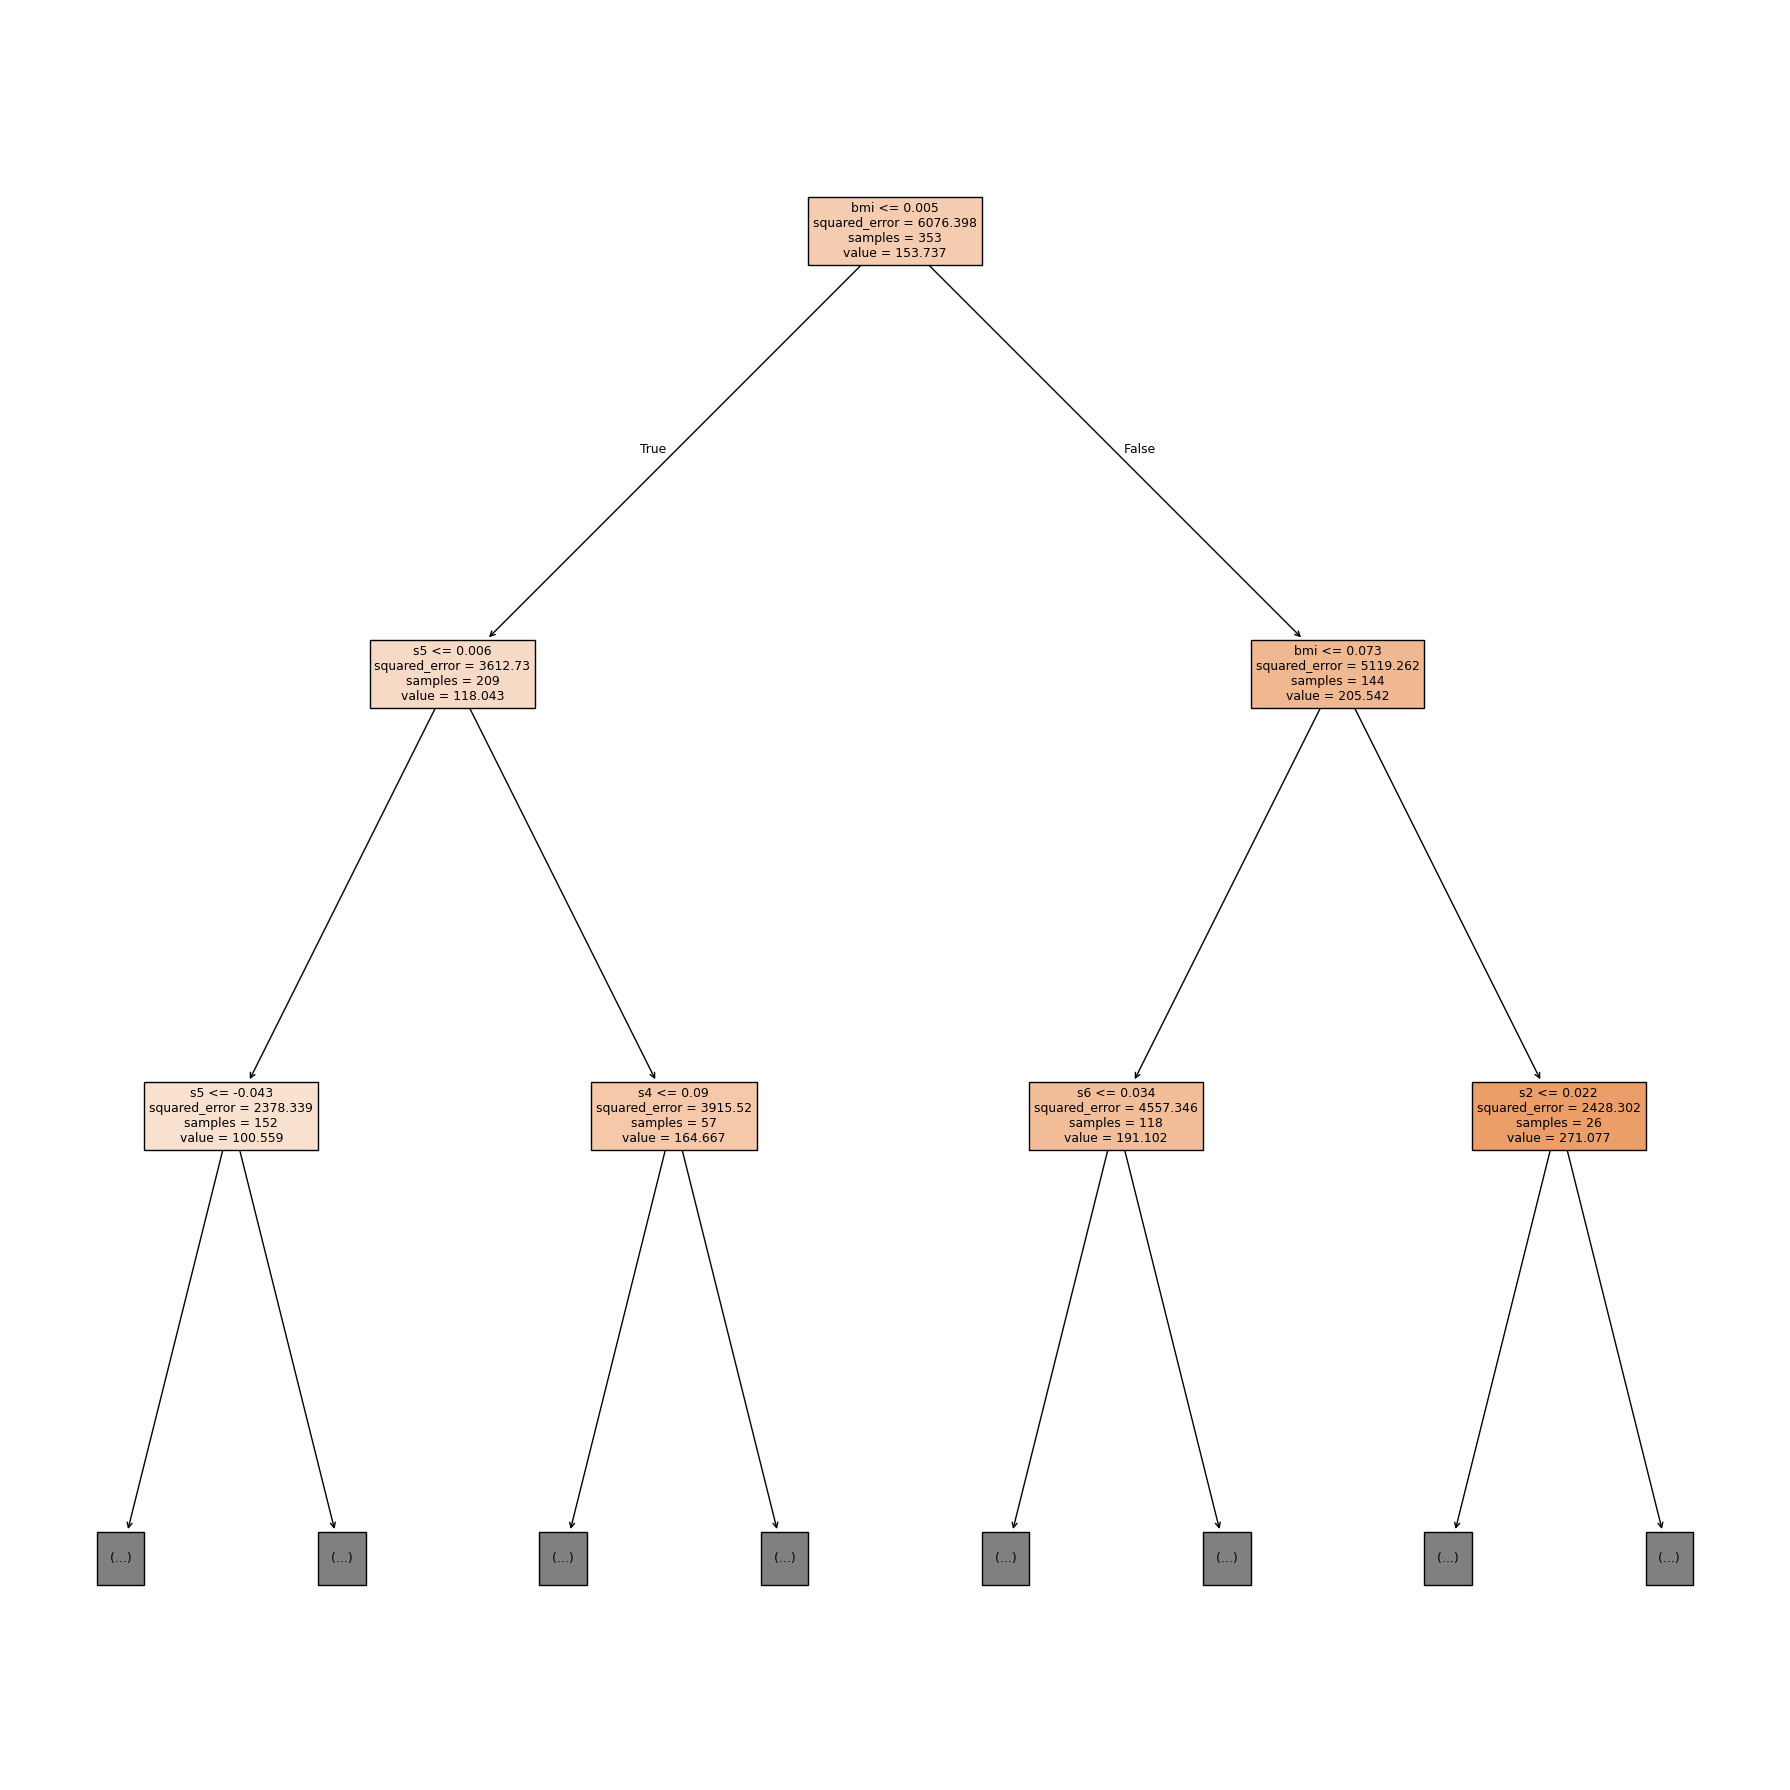

In [15]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 18))

plot_tree(
    model,
    feature_names=X.columns,
    filled=True,
    max_depth=2
)

plt.tight_layout()
plt.show()

In [16]:
# pre pruning ya post pruning kardo 
# rsquare test and r square train shopuld be near each other